In [1]:
import numpy as np
import itertools
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
mu1 = Pi**2 * M**(-2) * phic**(-1)
mu2 = 10
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 1 / mu1 - 2 * (phi - phic) / mu2**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 - 2 / mu2**2))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64
phimin = 0.999995 * phic
phimax = phic + 20 / mu1
psimax = psirc
psimin = 0.1 * psirc
customGrid_phi = np.linspace(phimin, phimax, nGrid)
customGrid_psir = np.linspace(psimin, psimax, nGrid)

In [3]:
phitest = phimin
psirtest = customGrid_psir[1]
Phitest = np.array([phitest, psirtest])
print(infPotFunc(Phitest))
print(infPotDerivFunc_phi(Phitest))
print((infPotFunc(Phitest + np.array([phitest * 0.01, 0])) - infPotFunc(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDerivFunc_psir(Phitest))
print((infPotFunc(Phitest + np.array([0, psirtest * 0.001])) - infPotFunc(Phitest - np.array([0, psirtest * 0.001]))) / (psirtest * 0.002))
print(infPotDeriv2Func_phi(Phitest))
print((infPotDerivFunc_phi(Phitest + np.array([phitest * 0.01, 0])) - infPotDerivFunc_phi(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDeriv2Func_psir(Phitest))
print((infPotDerivFunc_psir(Phitest + np.array([0, psirtest * 0.01])) - infPotDerivFunc_psir(Phitest - np.array([0, psirtest * 0.01]))) / (psirtest * 0.02))

2.309130063155654e-32
2.853929080794768e-42
2.7174487551341525e-42
-3.889683383387555e-48
0.0
-4.618260126311308e-34
-4.618260126311298e-34
-1.3770148664584386e-30
-1.3770148666168369e-30


In [4]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

# ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]
vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
            maskMat[i1, i2] = True
            fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [5]:
fpFinDiff_NeuNeu

array([[ 1563.85373917, -1563.85373917,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [ -517.94997019,  1563.85373917, -1045.90376898, ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,  -488.61920359,  1563.85373917, ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [    0.        ,     0.        ,     0.        , ...,
         1563.85373917,  -760.88761412,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
         -803.28014379,  1563.85373917,  -760.57359538],
       [    0.        ,     0.        ,     0.        , ...,
            0.        , -1563.85373917,  1563.85373917]])

In [6]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


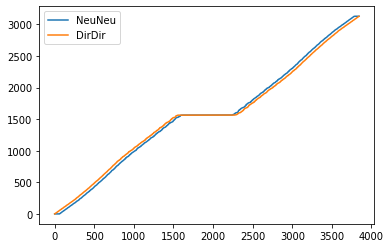

In [7]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

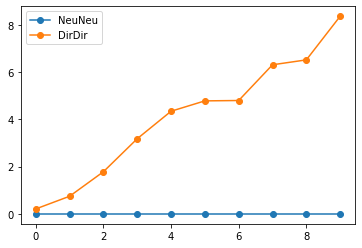

In [8]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [9]:
np.set_printoptions(formatter={'complexfloat': '{:.30f}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-0.000000000001148636741277186957-0.608636207045658572667434782488j
 -0.000000000001148636741277186957+0.608636207045658572667434782488j
 -0.000000000001020017403874362572-0.817982600984925922738000281242j
 -0.000000000001020017403874362572+0.817982600984925922738000281242j
 -0.000000000000929756271972337345-0.564533490536215598609715016210j
 -0.000000000000929756271972337345+0.564533490536215598609715016210j
 -0.000000000000781152920126260142-0.483476043192276216942104838381j
 -0.000000000000781152920126260142+0.483476043192276216942104838381j
 -0.000000000000694021229374897075-0.156817746388543566293805042733j
 -0.000000000000694021229374897075+0.156817746388543566293805042733j]
[0.211177918671827363761295259792+0.000000000000000000000000000000j
 0.746991375610098318205132272851+0.000000000000000000000000000000j
 1.783894288096124602915892864985+0.000000000000000000000000000000j
 3.179536667531844162937204600894+0.000000000000000000000000000000j
 4.341005038853682940214184782235+0.0

In [10]:
fpFinDiff_DirAll = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir]
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirAll[i1, i2] = 0

eigVals_DirAll, eigVecs_DirAll = np.linalg.eig(fpFinDiff_DirAll)
eigVecsSort_DirAll = eigVecs_DirAll.T[np.argsort(eigVals_DirAll)]
eigValsSort_DirAll = np.sort(eigVals_DirAll)


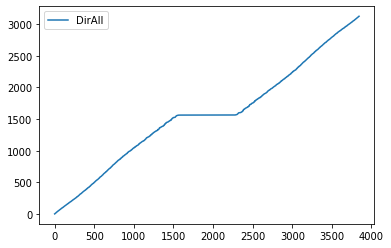

In [11]:
ax = plt.gca()
plt.plot(eigValsSort_DirAll, label = "DirAll")
plt.legend()
plt.show()

In [12]:
np.set_printoptions(formatter={'complexfloat': '{:.30f}'.format})
print(eigValsSort_DirAll[0:10])
np.set_printoptions()

[1.837868808539254050771205584169+0.000000000000000000000000000000j
 2.170453878208753017986509803450+0.000000000000000000000000000000j
 3.458217601901395710228825919330+0.000000000000000000000000000000j
 5.454434098282978204963455937104+0.000000000000000000000000000000j
 7.677922868505136833050528366584+0.000000000000000000000000000000j
 7.849795344588670786833972670138+0.000000000000000000000000000000j
 8.007335065080656733016439829953+0.000000000000000000000000000000j
 9.433217306039686889107542810962+0.000000000000000000000000000000j
 10.431421519962119859314952918794+0.000000000000000000000000000000j
 11.955723730287528994153944950085+0.000000000000000000000000000000j]


In [13]:
fpFinDiff_DirAll

array([[ 1563.85373917, -1016.57300238,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [ -517.94997019,  1563.85373917, -1045.90376898, ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,  -488.61920359,  1563.85373917, ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [    0.        ,     0.        ,     0.        , ...,
         1563.85373917,  -760.88761412,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
         -803.28014379,  1563.85373917,  -760.57359538],
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,  -825.26145546,  1563.85373917]])

c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


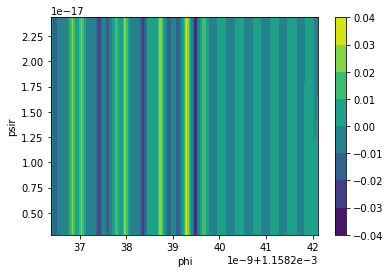

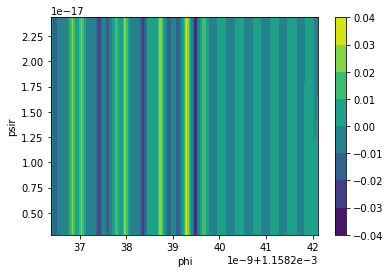

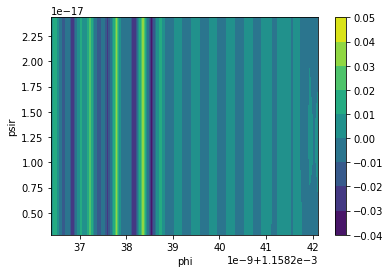

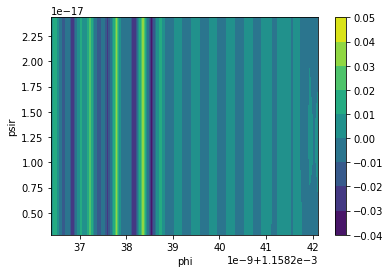

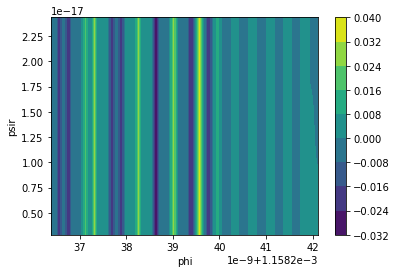

In [14]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], customGrid_psir[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

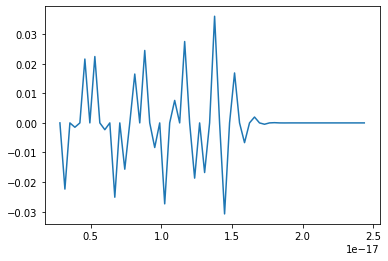

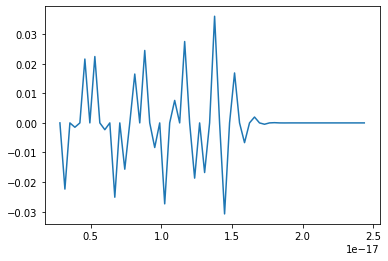

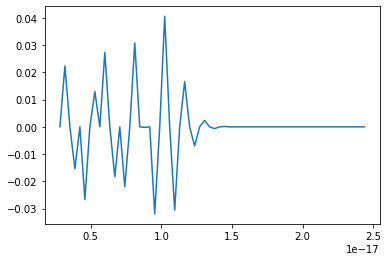

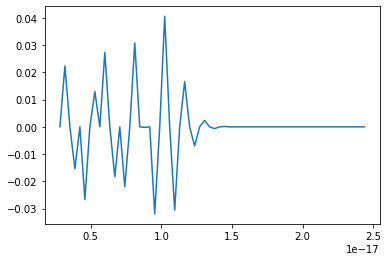

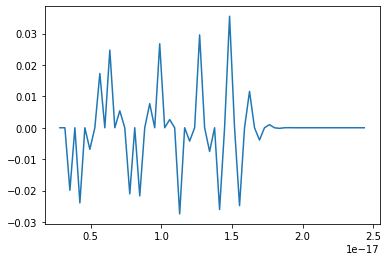

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[:,30])
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


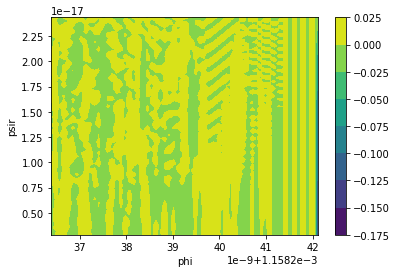

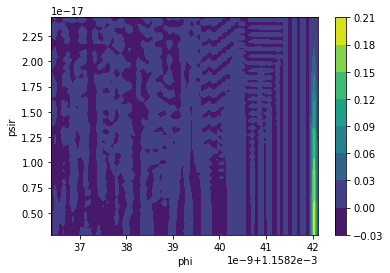

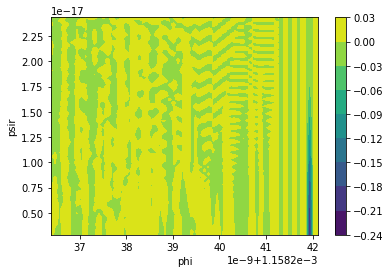

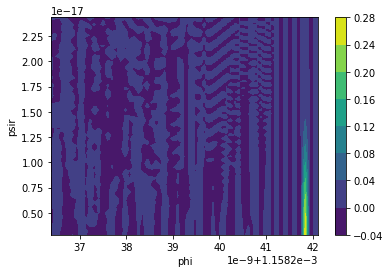

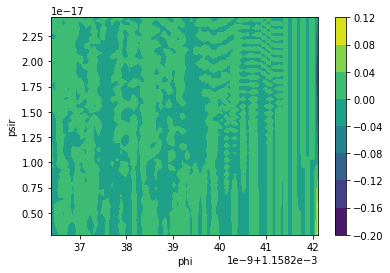

In [15]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], customGrid_psir[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


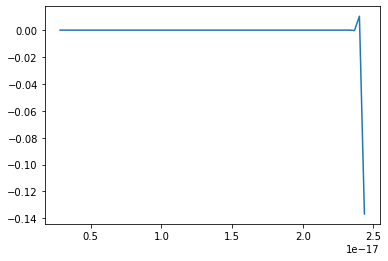

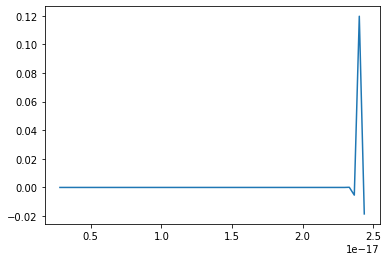

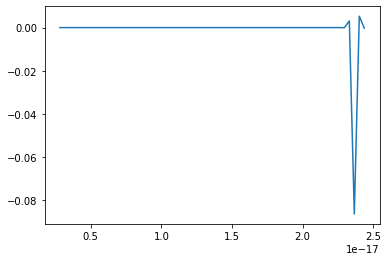

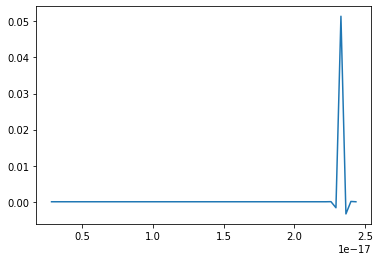

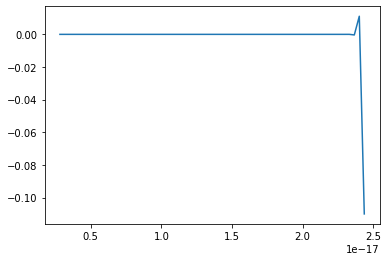

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30])
    plt.show()